# 🦜 Colombian Bird Song — Model Training

Train a ResNet50V2-based species classifier on log-Mel spectrogram tensors prepared by `pre-processing.ipynb`.

---

## Pipeline Overview

| Step | Description |
|------|-------------|
| 1 | Setup & install dependencies |
| 2 | Configuration |
| 3 | Mount Drive & configure paths |
| 4 | Load split & inspect class distribution |
| 5 | Build `tf.data` pipelines |
| 6 | Build model (ResNet50V2 + classification head) |
| 7 | Phase 1 — train classification head |
| 8 | Phase 2 — fine-tune top layers |
| 9 | Evaluation & diagnostics |
| 10 | Save model |
| 11 | Inference helper |

## Step 1 — Setup

Install required packages. Run once per Colab session.

In [1]:
%pip install tensorflow scikit-learn matplotlib seaborn --quiet

import tensorflow as tf
print(f"TensorFlow : {tf.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2 — Configuration

All training hyperparameters are set here. Change `FOLD_K` (0–4) to train on a different split.

In [2]:
# ── Split selection ───────────────────────────────────────────────────────
# 0–4: which of the 5 pre-built splits to use for this training run
FOLD_K = 1

# ── Data pipeline ─────────────────────────────────────────────────────────
BATCH_SIZE     = 32
SHUFFLE_BUFFER = 10_000   # set to len(train_dataset) after loading if memory allows

# ── Model ─────────────────────────────────────────────────────────────────
INPUT_HEIGHT   = 128
INPUT_WIDTH    = 188
DROPOUT_RATE   = 0.4
DENSE_UNITS    = 256

# ── Phase 1: train head only (base frozen) ────────────────────────────────
EPOCHS_PHASE1  = 30
LR_PHASE1      = 1e-3

# ── Phase 2: fine-tune top layers ─────────────────────────────────────────
EPOCHS_PHASE2  = 50
LR_PHASE2      = 1e-4       # 10× lower than phase 1
UNFREEZE_FROM  = -30        # unfreeze the last N layers of the ResNet base

# ── Callbacks ─────────────────────────────────────────────────────────────
EARLY_STOP_PATIENCE    = 6
REDUCE_LR_PATIENCE     = 3
REDUCE_LR_FACTOR       = 0.3

print("Configuration loaded.")
print(f"  Fold      : {FOLD_K}")
print(f"  Batch     : {BATCH_SIZE}")
print(f"  Phase 1   : {EPOCHS_PHASE1} epochs @ lr={LR_PHASE1}")
print(f"  Phase 2   : {EPOCHS_PHASE2} epochs @ lr={LR_PHASE2}  (unfreeze last {abs(UNFREEZE_FROM)} layers)")

Configuration loaded.
  Fold      : 1
  Batch     : 32
  Phase 1   : 30 epochs @ lr=0.001
  Phase 2   : 50 epochs @ lr=0.0001  (unfreeze last 30 layers)


## Step 3 — Mount Drive & Configure Paths

Set `USE_DRIVE = True` if splits are on Google Drive, `False` if on Colab local disk.

In [4]:
import zipfile
import shutil
from pathlib import Path

from google.colab import drive

# ── Mount Drive (source of the archive) ──────────────────────────────────
drive.mount("/content/drive")

DRIVE_BASE   = Path("/content/drive/MyDrive")
LOCAL_BASE   = Path("/content")

# ── Paths ─────────────────────────────────────────────────────────────────
DRIVE_ZIP    = DRIVE_BASE  / "bird_splits_archive/bird_splits_20260531_172008.zip"
LOCAL_ZIP    = LOCAL_BASE  / "bird_splits_archive.zip"
LOCAL_SPLITS = LOCAL_BASE  / "bird_splits"
MODELS_DIR   = DRIVE_BASE  / "bird_models"        # ← saved to Drive for persistence
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH  = MODELS_DIR / f"fold{FOLD_K}_best.weights.h5"
FINAL_MODEL_PATH = MODELS_DIR / f"resnet50v2_fold{FOLD_K}.keras"

# ── Copy & extract (skip if already done) ─────────────────────────────────
if LOCAL_SPLITS.exists():
    print(f"Local splits already exist at {LOCAL_SPLITS} — skipping copy.")
else:
    print(f"Copying {DRIVE_ZIP.name} from Drive to local disk ...")
    shutil.copy2(DRIVE_ZIP, LOCAL_ZIP)
    print("Extracting ...")
    with zipfile.ZipFile(LOCAL_ZIP, "r") as zf:
        zf.extractall(LOCAL_BASE)
    LOCAL_ZIP.unlink()   # free disk space
    print("Extraction complete.")

SPLITS_DIR = LOCAL_SPLITS

print(f"\nSplits dir   : {SPLITS_DIR}")
print(f"Models dir   : {MODELS_DIR}")

# ── List extracted files ──────────────────────────────────────────────────
print("\nFiles in splits directory:")
for f in sorted(SPLITS_DIR.iterdir()):
    size_mb = f.stat().st_size / 1_048_576
    print(f"  {f.name:<45}  {size_mb:6.1f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying bird_splits_20260531_172008.zip from Drive to local disk ...
Extracting ...
Extraction complete.

Splits dir   : /content/bird_splits
Models dir   : /content/drive/MyDrive/bird_models

Files in splits directory:
  label_map.json                                    0.0 MB
  split_0_train.npz                              2217.2 MB
  split_0_val.npz                                 553.5 MB
  split_1_train.npz                              2215.8 MB
  split_1_val.npz                                 554.9 MB
  split_2_train.npz                              2216.3 MB
  split_2_val.npz                                 554.4 MB
  split_3_train.npz                              2217.1 MB
  split_3_val.npz                                 553.7 MB
  split_4_train.npz                              2216.5 MB
  split_4_val.npz                                 554.2 MB
  

## Step 4 — Load Split & Inspect Class Distribution

Loads the train and val arrays for `FOLD_K`. Prints shape, dtype, and a class distribution summary to verify balance.

Classes      : 124
Train shape  : (32701, 128, 188)  dtype=float32
Val shape    : (8182, 128, 188)    dtype=int32
Val %        : 20.0%


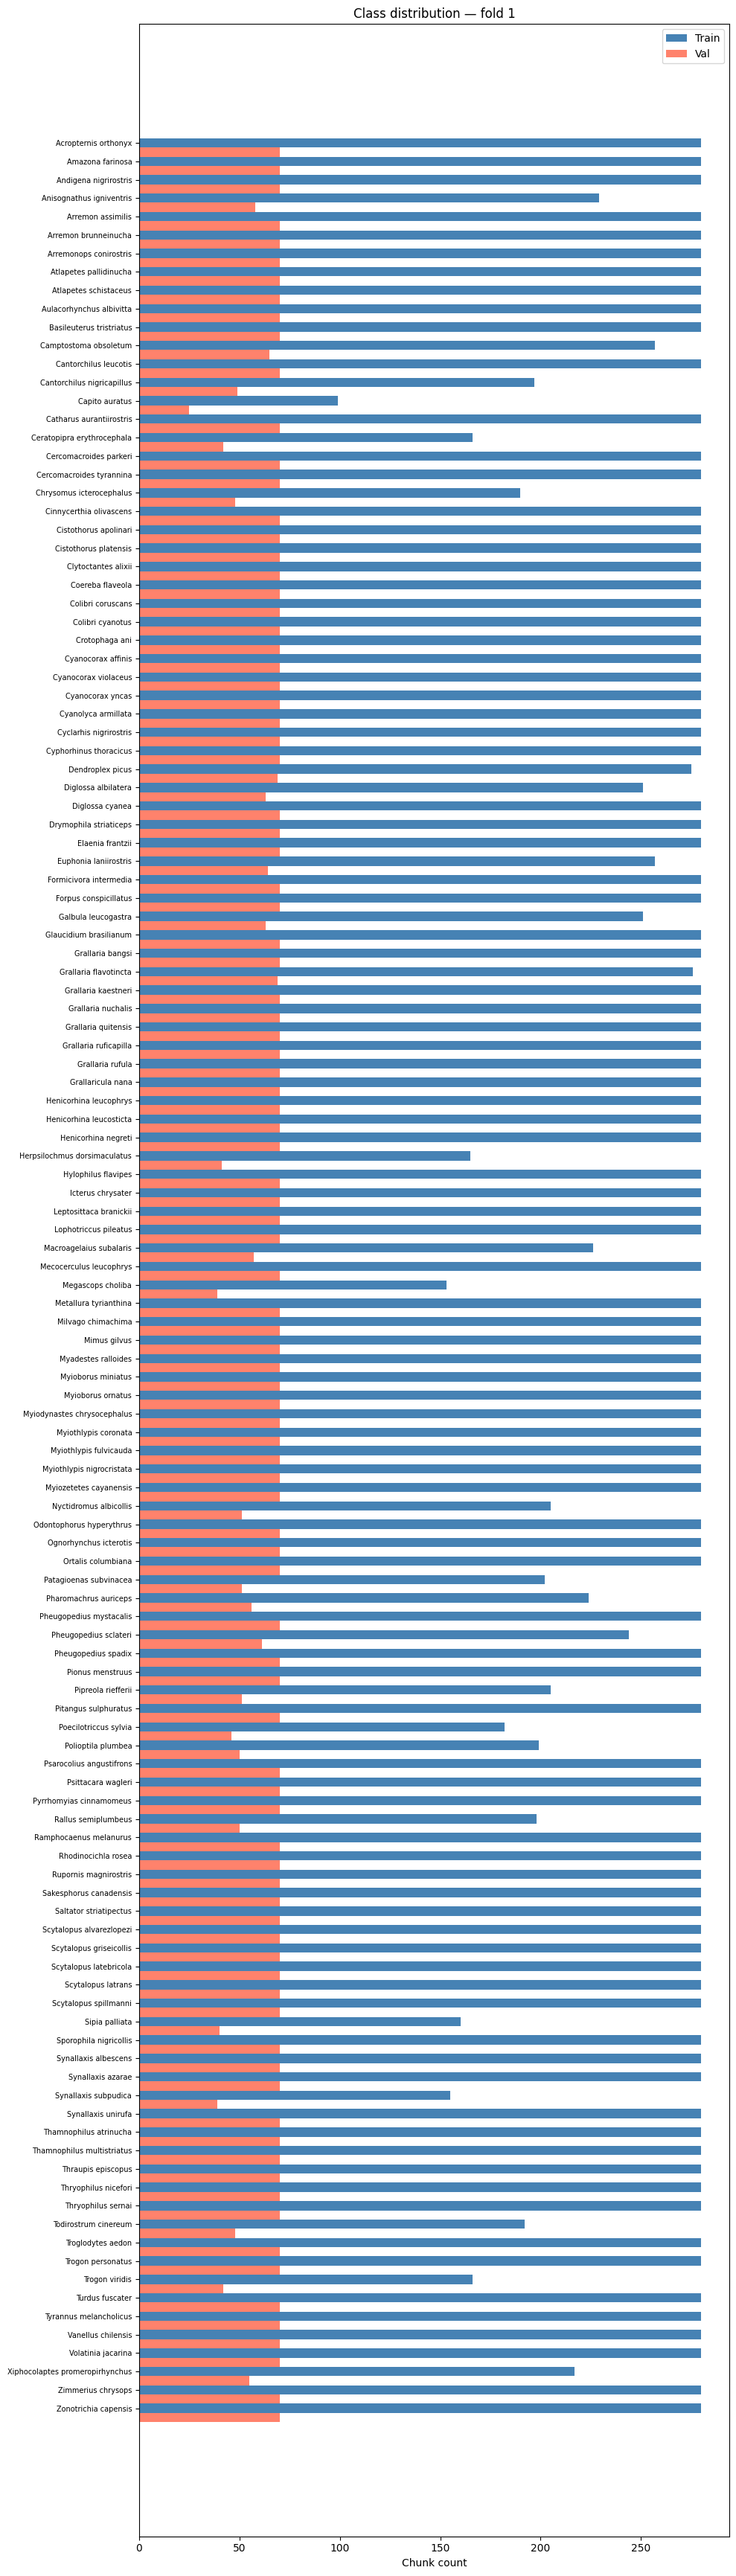

Train range  : [99, 280]  mean=263.7
Val range    : [25,   70]    mean=66.0


In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ── Load label map ────────────────────────────────────────────────────────
label_map_path = SPLITS_DIR / "label_map.json"
with open(label_map_path, "r", encoding="utf-8") as fh:
    label_map = {int(k): v for k, v in json.load(fh).items()}

N_CLASSES     = len(label_map)
species_names = [label_map[i] for i in range(N_CLASSES)]

print(f"Classes      : {N_CLASSES}")

# ── Load train / val arrays ───────────────────────────────────────────────
train_data = np.load(str(SPLITS_DIR / f"split_{FOLD_K}_train.npz"))
val_data   = np.load(str(SPLITS_DIR / f"split_{FOLD_K}_val.npz"))

X_train, y_train = train_data["spectrograms"], train_data["labels"]
X_val,   y_val   = val_data["spectrograms"],   val_data["labels"]

print(f"Train shape  : {X_train.shape}  dtype={X_train.dtype}")
print(f"Val shape    : {X_val.shape}    dtype={y_val.dtype}")
print(f"Val %        : {100 * len(y_val) / (len(y_train) + len(y_val)):.1f}%")

# ── Class distribution bar chart ──────────────────────────────────────────
train_counts = np.bincount(y_train, minlength=N_CLASSES)
val_counts   = np.bincount(y_val,   minlength=N_CLASSES)

fig_h = max(6, N_CLASSES * 0.28)
fig, ax = plt.subplots(figsize=(10, fig_h))
y_pos   = np.arange(N_CLASSES)
ax.barh(y_pos,        train_counts, height=0.5, label="Train", color="steelblue")
ax.barh(y_pos + 0.5,  val_counts,   height=0.5, label="Val",   color="tomato", alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([s.replace("_", " ") for s in species_names], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Chunk count")
ax.set_title(f"Class distribution — fold {FOLD_K}")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Train range  : [{train_counts.min()}, {train_counts.max()}]  mean={train_counts.mean():.1f}")
print(f"Val range    : [{val_counts.min()},   {val_counts.max()}]    mean={val_counts.mean():.1f}")

## Step 5 — Build `tf.data` Pipelines

Constructs optimised `tf.data` input pipelines:
- **Train**: expand dims → augment (flip, brightness, contrast) → cache → shuffle → batch → prefetch
- **Val**: expand dims → cache → batch → prefetch

`expand_dims` converts each `(128, 188)` tensor to `(128, 188, 1)` before batching.
Augmentation is applied only to training data.

In [6]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

def expand_and_cast(spec, label):
    spec = tf.expand_dims(spec, axis=-1)   # (128, 188) → (128, 188, 1)
    spec = tf.cast(spec, tf.float32)
    return spec, label

def augment(spec, label):
    spec = tf.image.random_flip_left_right(spec)
    spec = tf.image.random_brightness(spec, max_delta=0.1)
    spec = tf.image.random_contrast(spec, lower=0.8, upper=1.2)
    spec = tf.clip_by_value(spec, 0.0, 1.0)
    return spec, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(expand_and_cast, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=min(SHUFFLE_BUFFER, len(y_train)))
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(expand_and_cast, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("tf.data pipelines ready.")
for spec_batch, label_batch in train_ds.take(1):
    print(f"  Train batch: specs={spec_batch.shape}  labels={label_batch.shape}")
for spec_batch, label_batch in val_ds.take(1):
    print(f"  Val batch  : specs={spec_batch.shape}  labels={label_batch.shape}")

tf.data pipelines ready.
  Train batch: specs=(32, 128, 188, 1)  labels=(32,)
  Val batch  : specs=(32, 128, 188, 1)  labels=(32,)


## Step 6 — Build Model

Architecture:
```
Input (128, 188, 1)
  → Lambda: repeat grayscale channel × 3  →  (128, 188, 3)
  → ResNet50V2 backbone (ImageNet weights, top removed)
  → GlobalAveragePooling2D
  → BatchNormalization
  → Dense(256, relu)
  → Dropout(0.4)
  → Dense(N_CLASSES, softmax)
```

The Lambda layer converts the single-channel log-Mel spectrogram to 3 channels so that the pretrained ImageNet weights can be applied directly.

In [7]:
import tensorflow as tf

def build_model(n_classes, input_height, input_width, dropout_rate, dense_units):
    inputs = tf.keras.Input(shape=(input_height, input_width, 1), name="spectrogram")

    # Grayscale → 3-channel (required by pretrained ResNet50V2)
    # Concatenate instead of Lambda to avoid serialisation issues on load.
    x = tf.keras.layers.Concatenate(axis=-1, name="to_rgb")([inputs, inputs, inputs])

    # Pretrained backbone (weights frozen initially)
    base_model = tf.keras.applications.ResNet50V2(
        include_top=False,
        weights="imagenet",
        input_shape=(input_height, input_width, 3),
    )
    base_model.trainable = False

    x = base_model(x, training=False)

    # Classification head
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu", name="head_dense")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_dropout")(x)
    outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="predictions")(x)

    model = tf.keras.Model(inputs, outputs, name="BirdSongClassifier")
    return model, base_model


model, base_model = build_model(
    n_classes=N_CLASSES,
    input_height=INPUT_HEIGHT,
    input_width=INPUT_WIDTH,
    dropout_rate=DROPOUT_RATE,
    dense_units=DENSE_UNITS,
)

model.summary(line_length=90)
print(f"\nBase model trainable : {base_model.trainable}")
print(f"Total parameters     : {model.count_params():,}")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "BirdSongClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ spectrogram (InputLayer) │ (None, 128, 188, 1)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ to_rgb (Concatenate)     │ (None, 128, 188, 3)  │            0 │ spectrogram[0][0],    │
│                          │                      │              │ spectrogram[0][0],    │
│                          │                      │              │ spectrogram[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ resnet50v2 (Functional)  │ (None, 4, 6, 2048)   │   23,564,800 │ to_rgb[0][0]          │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ gap                      │ (None, 2048)         │            0 │ resnet50v2[0][0]      │
│ (GlobalAveragePooling2D) │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ head_bn                  │ (None, 2048)         │        8,192 │ gap[0][0]             │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ head_dense (Dense)       │ (None, 256)          │      524,544 │ head_bn[0][0]         │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ head_dropout (Dropout)   │ (None, 256)          │            0 │ head_dense[0][0]      │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ predictions (Dense)      │ (None, 124)          │       31,868 │ head_dropout[0][0]    │
└──────────────────────────┴──────────────────────┴──────────────┴───────────────────────┘

 Total params: 24,129,404 (92.05 MB)

 Trainable params: 560,508 (2.14 MB)

 Non-trainable params: 23,568,896 (89.91 MB)


Base model trainable : False
Total parameters     : 24,129,404


## Step 7 — Phase 1: Train Classification Head

The ResNet50V2 base is **frozen**. Only the new classification head layers are trained.

This lets the head adapt to the spectrogram feature space before any fine-tuning disturbs the pretrained weights.

In [8]:
import tensorflow as tf

# ── Compile ───────────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
    ],
)

# ── Callbacks ─────────────────────────────────────────────────────────────
callbacks_phase1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=REDUCE_LR_FACTOR,
        patience=REDUCE_LR_PATIENCE,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("Phase 1 — training classification head ...")
history_phase1 = model.fit(
    train_ds,
    epochs=EPOCHS_PHASE1,
    validation_data=val_ds,
    callbacks=callbacks_phase1,
    verbose=1,
)

val_acc_p1 = max(history_phase1.history["val_accuracy"])
print(f"\nPhase 1 complete. Best val accuracy: {val_acc_p1:.4f}")

Phase 1 — training classification head ...
Epoch 1/30
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2405 - loss: 3.5595 - top5_accuracy: 0.4638
Epoch 1: val_accuracy improved from None to 0.29406, saving model to /content/drive/MyDrive/bird_models/fold1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/bird_models/fold1_best.weights.h5
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 83s 63ms/step - accuracy: 0.2446 - loss: 3.5525 - top5_accuracy: 0.4686 - val_accuracy: 0.2941 - val_loss: 3.1546 - val_top5_accuracy: 0.5232 - learning_rate: 0.0010
Epoch 2/30
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3833 - loss: 2.5703 - top5_accuracy: 0.6477
Epoch 2: val_accuracy improved from 0.29406 to 0.37509, saving model to /content/drive/MyDrive/bird_models/fold1_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/bird_models/fold1_best.weights.h5
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 55s 54ms/step - accuracy: 0.3850 - loss: 2.6125 - top5_accuracy:

## Step 8 — Phase 2: Fine-Tune Top Layers

Unfreeze the **last `UNFREEZE_FROM` layers** of the ResNet50V2 base and continue training with a learning rate 10× lower than Phase 1 to preserve the pretrained representations.

In [9]:
import tensorflow as tf

# ── Unfreeze top layers of base ───────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Base layers now trainable : {trainable_count} / {len(base_model.layers)}")

# ── Recompile at lower LR ─────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
    ],
)

callbacks_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=REDUCE_LR_FACTOR,
        patience=REDUCE_LR_PATIENCE,
        min_lr=1e-8,
        verbose=1,
    ),
]

print("Phase 2 — fine-tuning top layers ...")
history_phase2 = model.fit(
    train_ds,
    initial_epoch=len(history_phase1.history["loss"]),
    epochs=len(history_phase1.history["loss"]) + EPOCHS_PHASE2,
    validation_data=val_ds,
    callbacks=callbacks_phase2,
    verbose=1,
)

val_acc_p2 = max(history_phase2.history["val_accuracy"])
print(f"\nPhase 2 complete. Best val accuracy: {val_acc_p2:.4f}")

Base layers now trainable : 30 / 190
Phase 2 — fine-tuning top layers ...
Epoch 31/80
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3994 - loss: 3.2598 - top5_accuracy: 0.6515
Epoch 31: val_accuracy improved from None to 0.55329, saving model to /content/drive/MyDrive/bird_models/fold1_best.weights.h5

Epoch 31: finished saving model to /content/drive/MyDrive/bird_models/fold1_best.weights.h5
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 131s 110ms/step - accuracy: 0.4624 - loss: 2.5302 - top5_accuracy: 0.7155 - val_accuracy: 0.5533 - val_loss: 1.8830 - val_top5_accuracy: 0.7783 - learning_rate: 1.0000e-04
Epoch 32/80
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5704 - loss: 1.7865 - top5_accuracy: 0.8061
Epoch 32: val_accuracy improved from 0.55329 to 0.62075, saving model to /content/drive/MyDrive/bird_models/fold1_best.weights.h5

Epoch 32: finished saving model to /content/drive/MyDrive/bird_models/fold1_best.weights.h5
1021/1021 ━━━━━━━━━━━━━━━━━━━━ 123s 120ms/step - acc

## Step 9 — Evaluation & Diagnostics

Four diagnostic outputs:
1. **Learning curves** — train/val accuracy and loss across both phases
2. **Confusion matrix** — predicted vs. true species (normalised by row)
3. **Per-class accuracy** — horizontal bar chart, sorted ascending
4. **Summary metrics** — top-1 accuracy, top-5 accuracy, macro F1, weighted F1

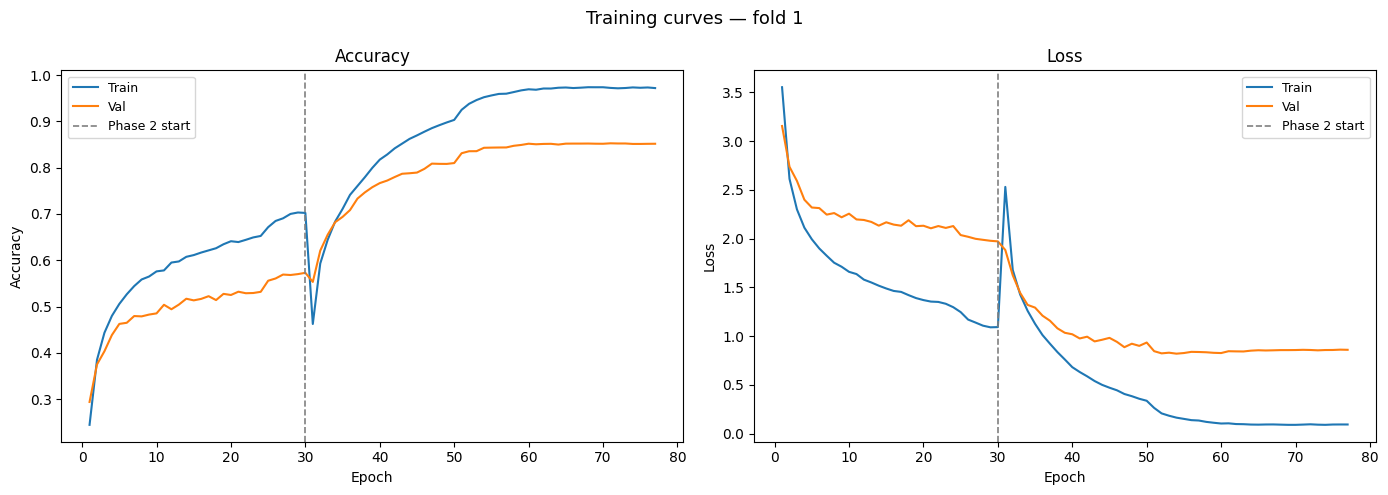

Running inference on validation set ...


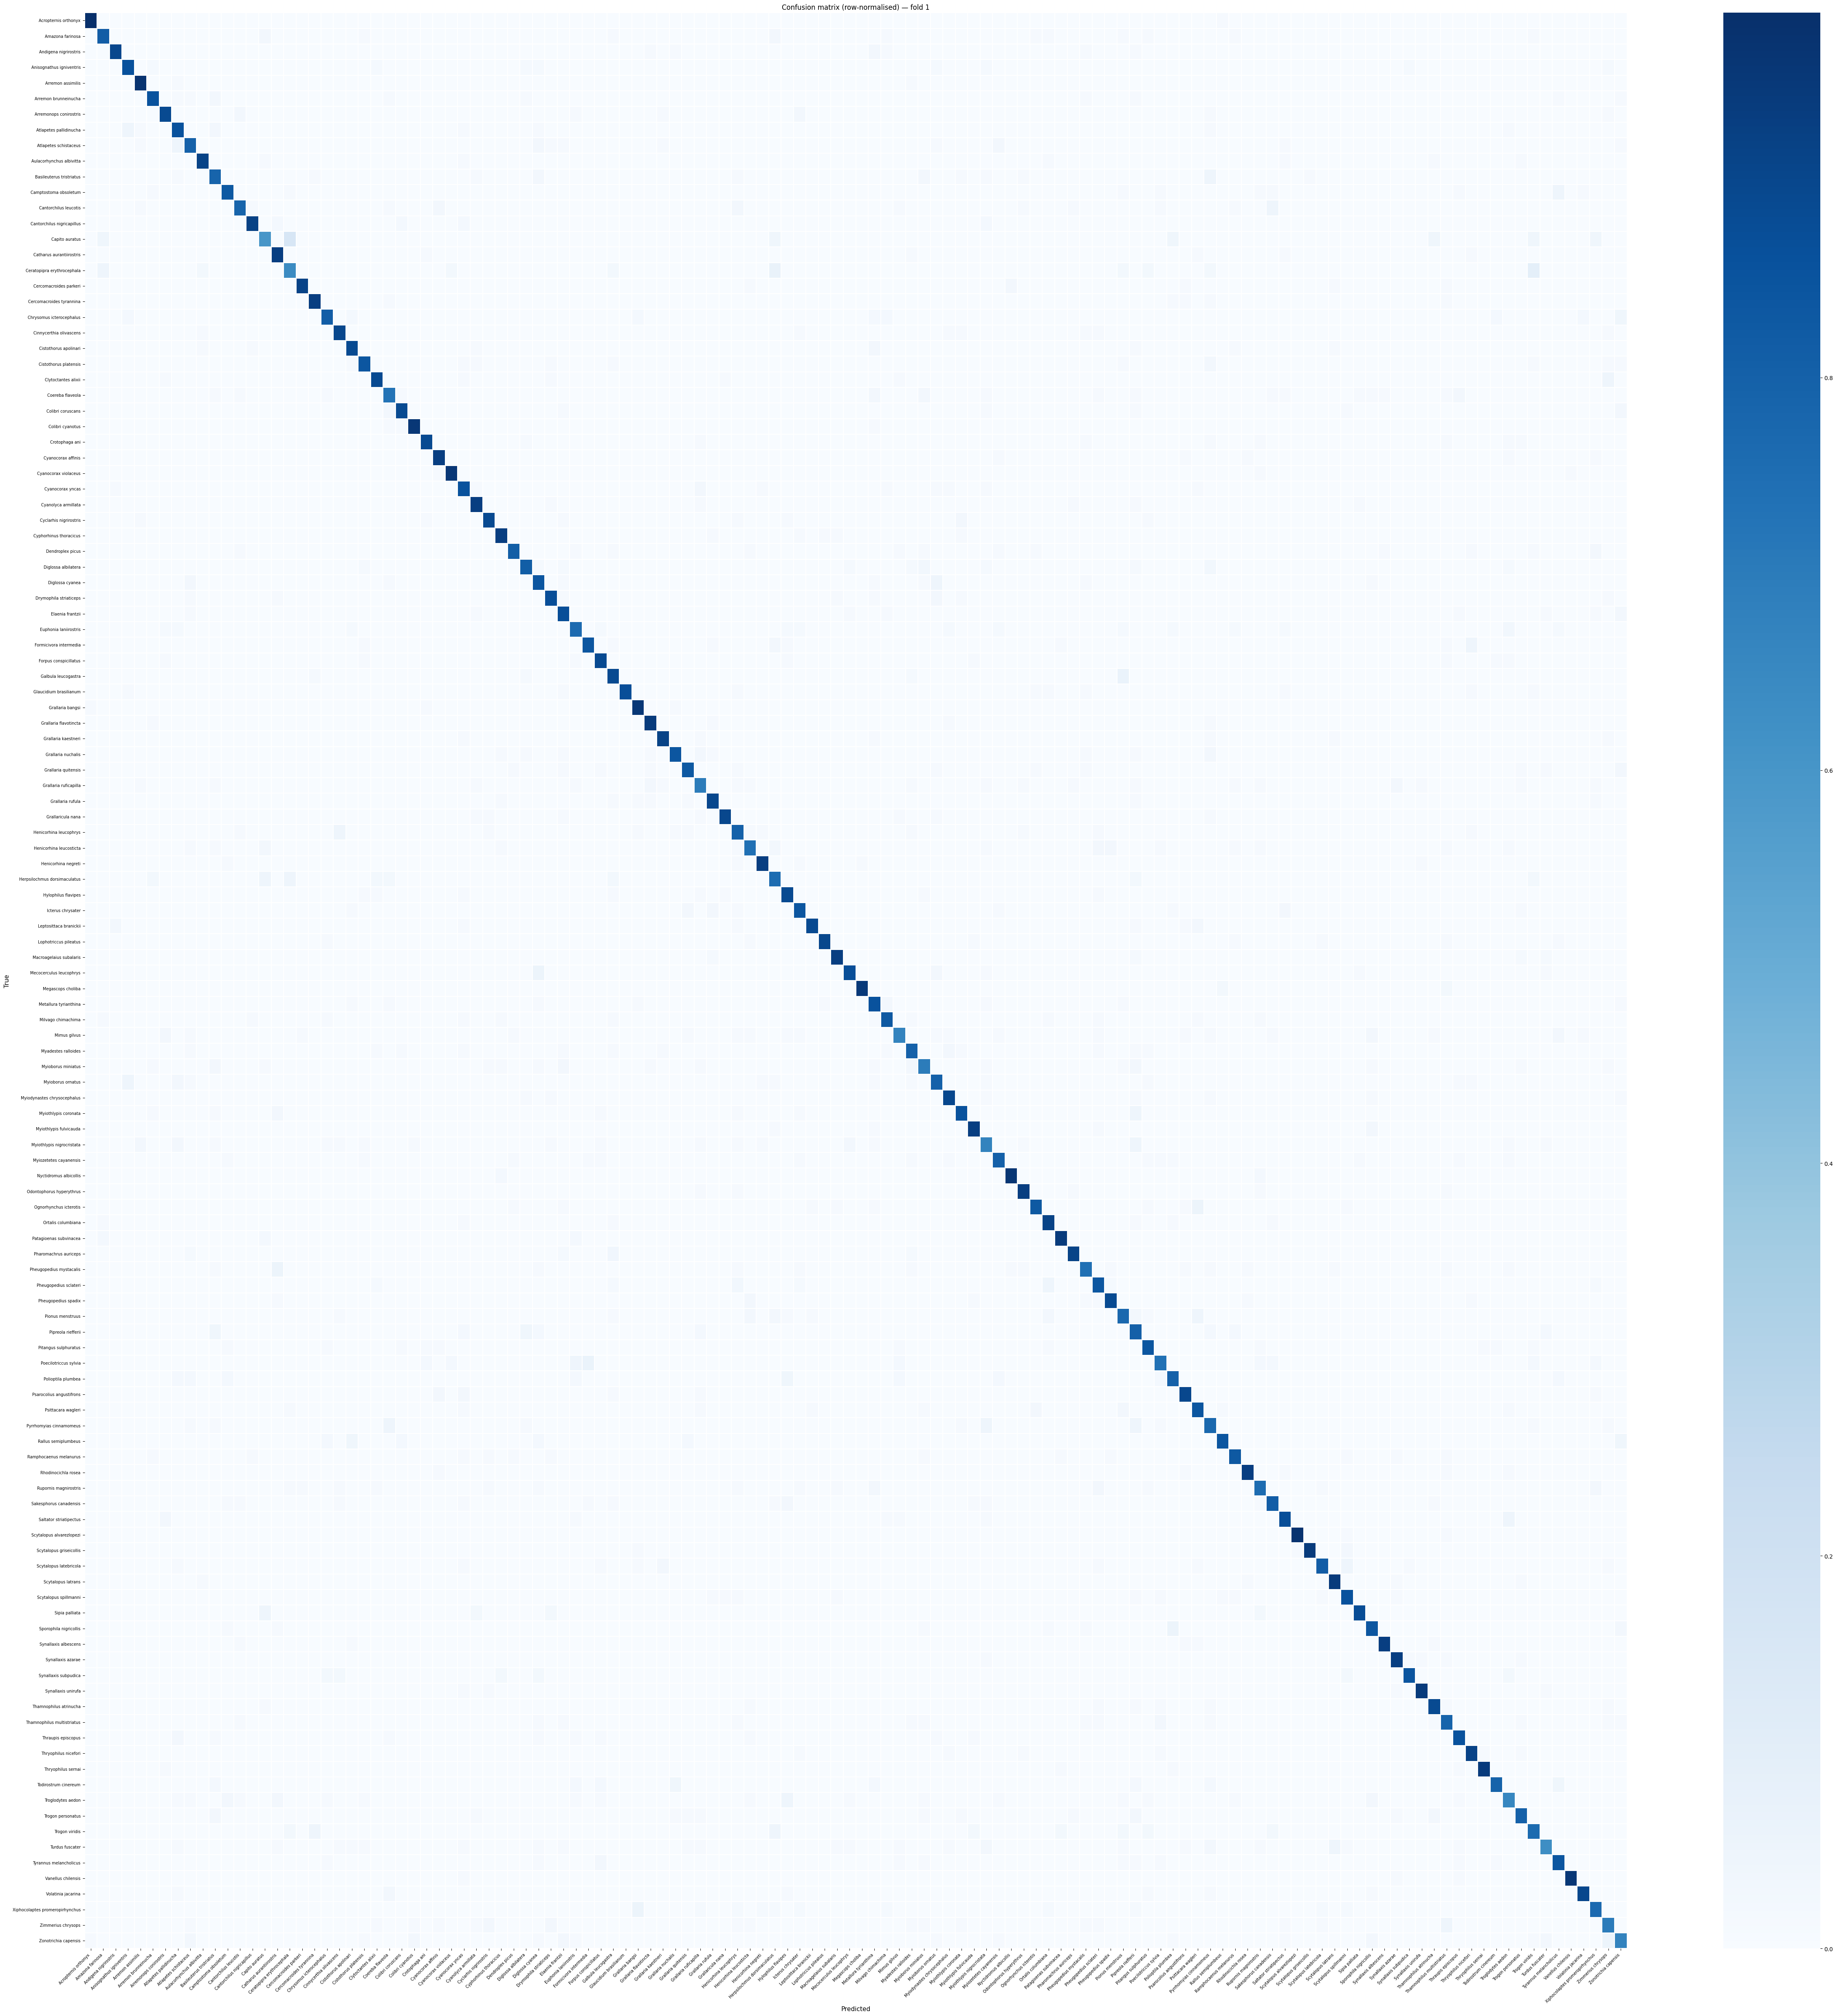

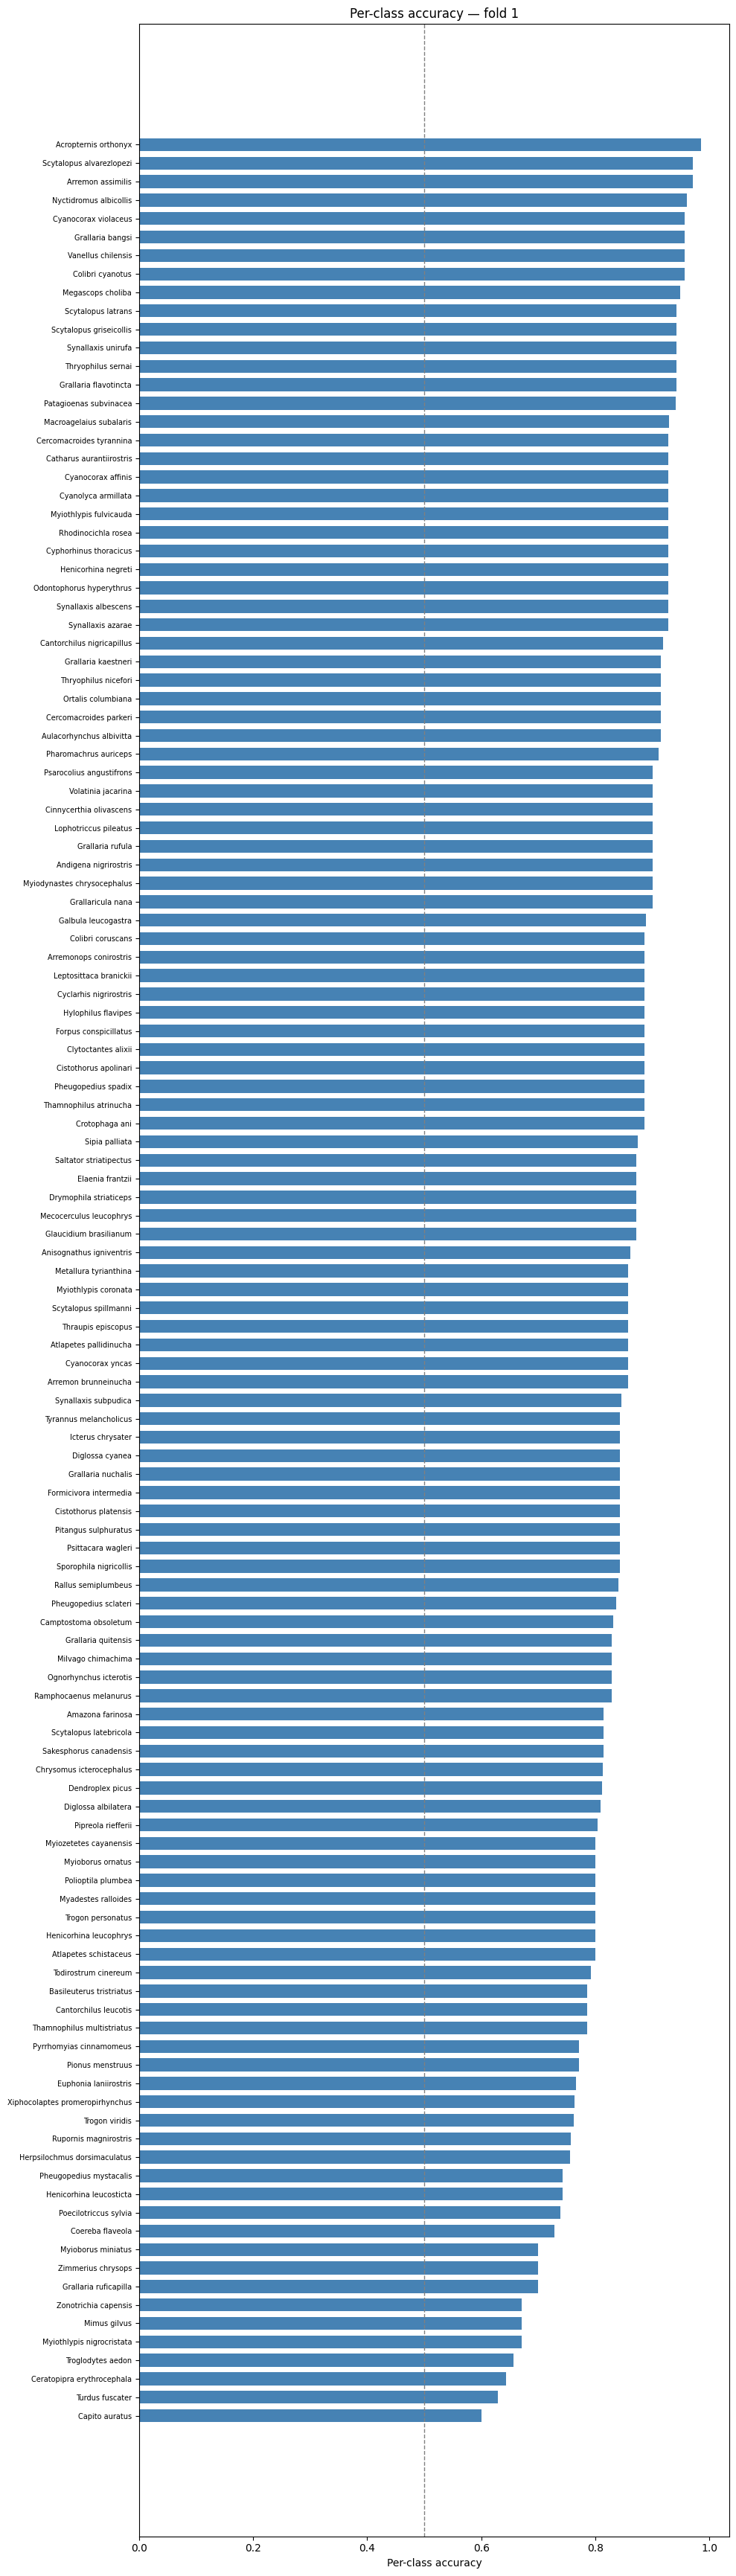


  Top-1 accuracy : 0.8526
  Top-5 accuracy : 0.9371
  Macro F1       : 0.8501
  Weighted F1    : 0.8530

Worst 5 species: ['Capito auratus', 'Turdus fuscater', 'Ceratopipra erythrocephala', 'Troglodytes aedon', 'Myiothlypis nigrocristata']
Best  5 species: ['Cyanocorax violaceus', 'Nyctidromus albicollis', 'Arremon assimilis', 'Scytalopus alvarezlopezi', 'Acropternis orthonyx']


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, f1_score, top_k_accuracy_score
)

# ── 1. Learning curves (phases 1 + 2 combined) ───────────────────────────
acc      = history_phase1.history["accuracy"]     + history_phase2.history["accuracy"]
val_acc  = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
loss     = history_phase1.history["loss"]         + history_phase2.history["loss"]
val_loss = history_phase1.history["val_loss"]     + history_phase2.history["val_loss"]
phase_boundary = len(history_phase1.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Training curves — fold {FOLD_K}", fontsize=13)

for ax, train_vals, val_vals, ylabel in zip(
    axes,
    [acc, loss],
    [val_acc, val_loss],
    ["Accuracy", "Loss"],
):
    epochs = range(1, len(train_vals) + 1)
    ax.plot(epochs, train_vals, label="Train")
    ax.plot(epochs, val_vals,   label="Val")
    ax.axvline(phase_boundary, color="gray", linestyle="--", linewidth=1.2, label="Phase 2 start")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(MODELS_DIR / f"fold{FOLD_K}_learning_curves.png"), dpi=120)
plt.show()

# ── 2. Predictions on val set ─────────────────────────────────────────────
print("Running inference on validation set ...")
y_prob = model.predict(val_ds, verbose=0)   # (M, N_CLASSES)
y_pred = np.argmax(y_prob, axis=1)

# ── 3. Confusion matrix ───────────────────────────────────────────────────
cm     = confusion_matrix(y_val, y_pred, normalize="true")
labels = [s.replace("_", " ") for s in species_names]
fig_sz = max(12, N_CLASSES * 0.4)

fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))
sns.heatmap(cm, annot=N_CLASSES <= 30, fmt=".2f",
            xticklabels=labels, yticklabels=labels,
            cmap="Blues", linewidths=0.3, ax=ax)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.set_title(f"Confusion matrix (row-normalised) — fold {FOLD_K}", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(str(MODELS_DIR / f"fold{FOLD_K}_confusion_matrix.png"), dpi=120)
plt.show()

# ── 4. Per-class accuracy bar chart ──────────────────────────────────────
per_class_acc = cm.diagonal()
sorted_idx    = np.argsort(per_class_acc)

fig, ax = plt.subplots(figsize=(10, max(6, N_CLASSES * 0.28)))
colors  = ["tomato" if v < 0.5 else "steelblue" for v in per_class_acc[sorted_idx]]
ax.barh(range(N_CLASSES), per_class_acc[sorted_idx], color=colors, height=0.7)
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels([labels[i] for i in sorted_idx], fontsize=7)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1.0)
ax.set_xlabel("Per-class accuracy")
ax.set_title(f"Per-class accuracy — fold {FOLD_K}")
plt.tight_layout()
plt.savefig(str(MODELS_DIR / f"fold{FOLD_K}_per_class_accuracy.png"), dpi=120)
plt.show()

# ── 5. Summary metrics ────────────────────────────────────────────────────
top1_acc    = np.mean(y_pred == y_val)
top5_acc    = top_k_accuracy_score(y_val, y_prob, k=5)
macro_f1    = f1_score(y_val, y_pred, average="macro",    zero_division=0)
weighted_f1 = f1_score(y_val, y_pred, average="weighted", zero_division=0)

print("\n" + "=" * 40)
print(f"  Top-1 accuracy : {top1_acc:.4f}")
print(f"  Top-5 accuracy : {top5_acc:.4f}")
print(f"  Macro F1       : {macro_f1:.4f}")
print(f"  Weighted F1    : {weighted_f1:.4f}")
print("=" * 40)

worst5 = [labels[i] for i in sorted_idx[:5]]
best5  = [labels[i] for i in sorted_idx[-5:]]
print(f"\nWorst 5 species: {worst5}")
print(f"Best  5 species: {best5}")

## Step 10 — Save Model

Saves the trained model in Keras native format. The checkpoint with the best validation accuracy (saved during training) is already loaded via `restore_best_weights=True` in the EarlyStopping callback.

In [11]:
model.save(str(FINAL_MODEL_PATH))
print(f"Model saved : {FINAL_MODEL_PATH}")
print(f"\nTo restore:")
print(f"  import tensorflow as tf")
print(f"  model = tf.keras.models.load_model('{FINAL_MODEL_PATH}')")

Model saved : /content/drive/MyDrive/bird_models/resnet50v2_fold1.keras

To restore:
  import tensorflow as tf
  model = tf.keras.models.load_model('/content/drive/MyDrive/bird_models/resnet50v2_fold1.keras')


## Step 11 — Inference Helper

Given any raw audio file, runs the full pre-processing chain and returns the **top-3 predicted species** with confidence scores.

The pre-processing parameters (SR, chunk size, bandpass filter, mel settings, normalisation) match those used in `pre-processing.ipynb` Steps 6 and 8.

> **Fully Independent:** Because this cell loads the complete model from disk, you can run only Step 1 (`%pip install...`) and this cell upon restarting the notebook. Just verify the paths for `MODEL_PATH`, `LABEL_MAP_PATH`, and `AUDIO_PATH`.

In [ ]:
%pip install librosa soundfile scipy --quiet

import json
import numpy as np
import librosa
import tensorflow as tf
from pathlib import Path
from scipy.signal import butter, sosfilt

# ── Files and Paths ───────────────────────────────────────────────────────
MODEL_PATH     = Path("resnet50v2_fold2.keras")
LABEL_MAP_PATH = Path("data/label_map.json")

# ── Point to an audio file (required) ─────────────────────────────────────
AUDIO_PATH = "bird_audio.mpeg"

if AUDIO_PATH is None or not Path(AUDIO_PATH).exists():
    raise ValueError(f"Please set AUDIO_PATH to an existing audio file. Current value: {AUDIO_PATH}")

# ── Pre-processing constants (must match pre-processing.ipynb) ────────────
SR             = 32_000
CHUNK_LEN      = 3.0
CHUNK_SAMPLES  = int(SR * CHUNK_LEN)
STRIDE_SAMPLES = CHUNK_SAMPLES // 2
BUTTER_LOW_HZ  = 1_000
BUTTER_HIGH_HZ = 15_000
N_FFT          = 2048
HOP_LENGTH     = 512
N_MELS         = 128
TARGET_FRAMES  = 188
DB_MIN         = -80.0
DB_MAX         = 0.0

# ── Load Label Map and Model ──────────────────────────────────────────────
if not LABEL_MAP_PATH.exists():
    raise FileNotFoundError(f"Label map not found at {LABEL_MAP_PATH}. Extract splits first.")

with open(LABEL_MAP_PATH, "r", encoding="utf-8") as fh:
    label_map = {int(k): v for k, v in json.load(fh).items()}

print(f"Loading model from {MODEL_PATH.name}...")
model = tf.keras.models.load_model(str(MODEL_PATH))
print("Model loaded successfully.")

# ── Setup functions ───────────────────────────────────────────────────────
def make_bandpass_sos(low_hz, high_hz, sr, order=5):
    nyq = sr / 2.0
    return butter(order, [low_hz / nyq, high_hz / nyq], btype="band", output="sos")

def audio_to_chunks(audio):
    sos      = make_bandpass_sos(BUTTER_LOW_HZ, BUTTER_HIGH_HZ, SR)
    filtered = sosfilt(sos, audio).astype(np.float32)
    return [
        filtered[s : s + CHUNK_SAMPLES].copy()
        for s in range(0, len(filtered) - CHUNK_SAMPLES + 1, STRIDE_SAMPLES)
    ]

def chunk_to_tensor(chunk):
    mel    = librosa.feature.melspectrogram(
        y=chunk, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    db     = librosa.power_to_db(mel, ref=np.max)
    tensor = (np.clip(db, DB_MIN, DB_MAX) - DB_MIN) / (DB_MAX - DB_MIN)
    if tensor.shape[1] < TARGET_FRAMES:
        tensor = np.pad(tensor, ((0, 0), (0, TARGET_FRAMES - tensor.shape[1])))
    else:
        tensor = tensor[:, :TARGET_FRAMES]
    return tensor.astype(np.float32)

# ── Inference ─────────────────────────────────────────────────────────────
audio, _ = librosa.load(AUDIO_PATH, sr=SR, mono=True)
source_label = Path(AUDIO_PATH).name
chunks  = audio_to_chunks(audio)

if not chunks:
    raise ValueError("Audio is too short to extract any valid chunks.")

tensors = np.stack([chunk_to_tensor(c) for c in chunks], axis=0)

print(f"Source  : {source_label}")
print(f"Chunks  : {len(chunks)}")

# ── Predict ───────────────────────────────────────────────────────────────
tensors_in  = np.expand_dims(tensors, axis=-1)     # (K, 128, 188, 1)
chunk_probs = model.predict(tensors_in, verbose=0) # (K, N_CLASSES)
avg_probs   = chunk_probs.mean(axis=0)             # average across chunks

top3_indices = np.argsort(avg_probs)[::-1][:3]

print("\n── Top-3 predicted species ──────────────────")
for rank, idx in enumerate(top3_indices, 1):
    species    = label_map[idx].replace("_", " ")
    confidence = avg_probs[idx] * 100
    print(f"  {rank}. {species:<40}  {confidence:5.1f}%")
print("─────────────────────────────────────────────")